Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

Load & Prepare Data

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving era5_nyc_summer_accum.csv to era5_nyc_summer_accum.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving era5_sep2025_multigrid.csv to era5_sep2025_multigrid.csv


In [ ]:
import pandas as pd

# Train: June–August
train_df = pd.read_csv("era5_nyc_summer_accum.csv", parse_dates=["valid_time"])

# Test: September
test_df = pd.read_csv("era5_sep2025_multigrid.csv", parse_dates=["valid_time"])

# Sort properly
train_df = train_df.sort_values(["latitude", "longitude", "valid_time"]).reset_index(drop=True)
test_df  = test_df.sort_values(["latitude", "longitude", "valid_time"]).reset_index(drop=True)

In [ ]:
features = ["temp_C", "ssrd", "wind_speed"]

train_df = train_df[["valid_time","latitude","longitude"] + features]
test_df  = test_df[["valid_time","latitude","longitude"] + features]

# Rename to standard names
train_df = train_df.rename(columns={
    "temp_C": "T",
    "ssrd": "R",
    "wind_speed": "W"
})

test_df = test_df.rename(columns={
    "temp_C": "T",
    "ssrd": "R",
    "wind_speed": "W"
})

Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_df[["T","R","W"]] = scaler.fit_transform(train_df[["T","R","W"]])
test_df[["T","R","W"]]  = scaler.transform(test_df[["T","R","W"]])

Sequence Builder pe grid

In [ ]:
import numpy as np

SEQ_LEN = 7   # since DAILY data (use 7 days history)

def build_sequences(df, seq_len):
    X_all, y_all = [], []

    for (lat, lon), group in df.groupby(["latitude", "longitude"]):

        group = group.sort_values("valid_time")
        data = group[["T","R","W"]].values

        if len(data) <= seq_len:
            continue

        for i in range(len(data) - seq_len):
            X_all.append(data[i:i+seq_len])
            y_all.append(data[i+seq_len, 0])  # predict T

    return np.array(X_all), np.array(y_all)

X_train, y_train = build_sequences(train_df, SEQ_LEN)
X_test,  y_test  = build_sequences(test_df, SEQ_LEN)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (99045, 7, 3)
Test : (24955, 7, 3)


Dataset & Loader

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesDataset(X_train, y_train),
                          batch_size=128, shuffle=True)

test_loader = DataLoader(TimeSeriesDataset(X_test, y_test),
                         batch_size=128, shuffle=False)

LSTM Model

In [ ]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size,
                            num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out).squeeze()

Training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(Xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")

Epoch 1, Loss: 0.004277
Epoch 2, Loss: 0.000398
Epoch 3, Loss: 0.000258
Epoch 4, Loss: 0.000228
Epoch 5, Loss: 0.000217
Epoch 6, Loss: 0.000212
Epoch 7, Loss: 0.000212
Epoch 8, Loss: 0.000207
Epoch 9, Loss: 0.000207
Epoch 10, Loss: 0.000200
Epoch 11, Loss: 0.000199
Epoch 12, Loss: 0.000196
Epoch 13, Loss: 0.000193
Epoch 14, Loss: 0.000194
Epoch 15, Loss: 0.000189
Epoch 16, Loss: 0.000188
Epoch 17, Loss: 0.000183
Epoch 18, Loss: 0.000181
Epoch 19, Loss: 0.000182
Epoch 20, Loss: 0.000176


One-Step Evaluation (September)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

model.eval()
preds = []

with torch.no_grad():
    for Xb, _ in test_loader:
        Xb = Xb.to(device)
        out = model(Xb)
        preds.append(out.cpu().numpy())

preds = np.concatenate(preds)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("One-step RMSE:", rmse)

One-step RMSE: 0.01600051771014581


In [ ]:
one_step_records = []

model.eval()

for (lat, lon), group in test_df.groupby(["latitude", "longitude"]):

    group = group.sort_values("valid_time")
    data = group[["T","R","W"]].values
    times = group["valid_time"].values

    if len(data) <= SEQ_LEN:
        continue

    for i in range(len(data) - SEQ_LEN):

        X_seq = data[i:i+SEQ_LEN]
        true_T = data[i+SEQ_LEN, 0]
        time_t = times[i+SEQ_LEN]

        x = torch.tensor(X_seq[np.newaxis,:,:], dtype=torch.float32).to(device)

        with torch.no_grad():
            pred_T = model(x).item()

        one_step_records.append({
            "time": time_t,
            "latitude": lat,
            "longitude": lon,
            "true_T": true_T,
            "pred_T": pred_T
        })

one_step_df = pd.DataFrame(one_step_records)

In [ ]:
one_step_df.to_csv("lstm_one_step_september.csv", index=False)


Plot one-step prediction for selected grids

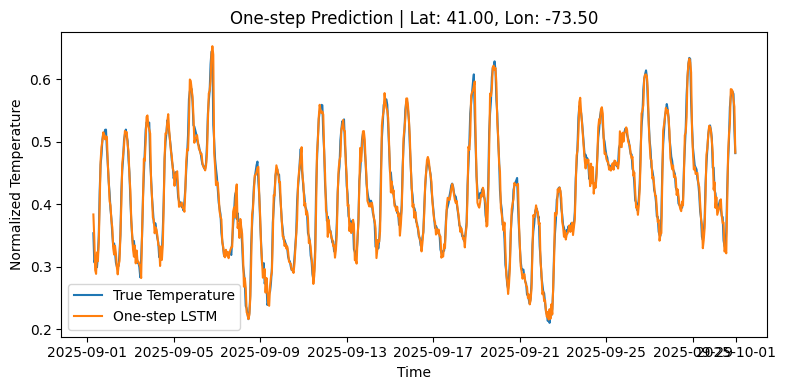

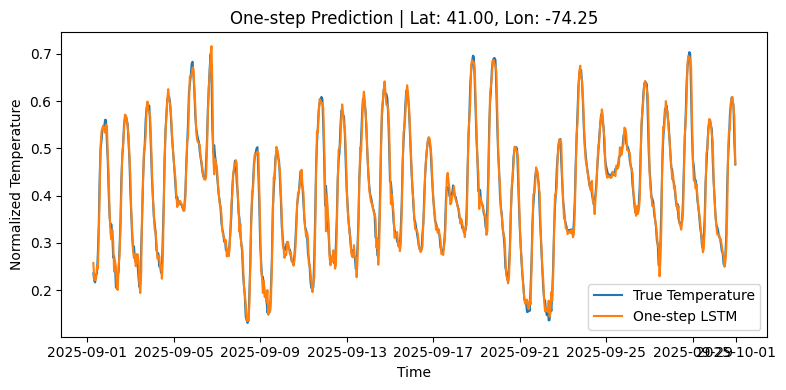

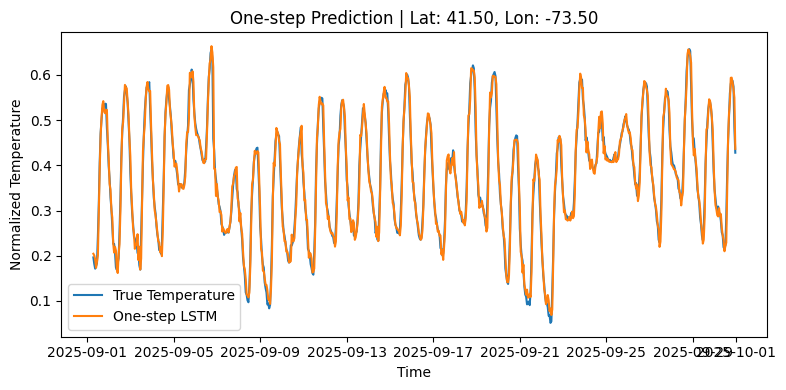

In [ ]:
import matplotlib.pyplot as plt
import random

# Ensure time is datetime
one_step_df["time"] = pd.to_datetime(one_step_df["time"])

# Group by grid
groups = list(one_step_df.groupby(["latitude", "longitude"]))

# Select a few grids
sample_groups = random.sample(groups, 3)

for (lat, lon), group in sample_groups:

    group = group.sort_values("time")

    plt.figure(figsize=(8,4))
    plt.plot(group["time"], group["true_T"], label="True Temperature")
    plt.plot(group["time"], group["pred_T"], label="One-step LSTM")

    plt.title(f"One-step Prediction | Lat: {lat:.2f}, Lon: {lon:.2f}")
    plt.xlabel("Time")
    plt.ylabel("Normalized Temperature")
    plt.legend()
    plt.tight_layout()
    plt.show()

Multi-Step Forward Simulation per grid

In [ ]:
def multi_step_forecast(model, df, seq_len):
    results = []

    for (lat, lon), group in df.groupby(["latitude", "longitude"]):

        group = group.sort_values("valid_time")
        data = group[["T","R","W"]].values

        if len(data) <= seq_len:
            continue

        init_seq = data[:seq_len]
        future_exog = data[seq_len:, 1:]  # R, W
        true_T = data[seq_len:, 0]

        seq = init_seq.copy()
        preds = []

        for i in range(len(future_exog)):
            x = torch.tensor(seq[np.newaxis,:,:], dtype=torch.float32).to(device)

            with torch.no_grad():
                pred_T = model(x).item()

            R_next, W_next = future_exog[i]
            next_step = np.array([pred_T, R_next, W_next])

            preds.append(pred_T)
            seq = np.vstack([seq[1:], next_step])

        results.append((np.array(preds), true_T))

    return results

Multi-Step Evaluation

In [ ]:
multi_results = multi_step_forecast(model, test_df, SEQ_LEN)

rmses = []

for preds, true_T in multi_results:
    rmse = np.sqrt(mean_squared_error(true_T, preds))
    rmses.append(rmse)

print("Multi-step RMSE (mean over grids):", np.mean(rmses))

Multi-step RMSE (mean over grids): 0.11476626791883097


Run Forward Simulation on September

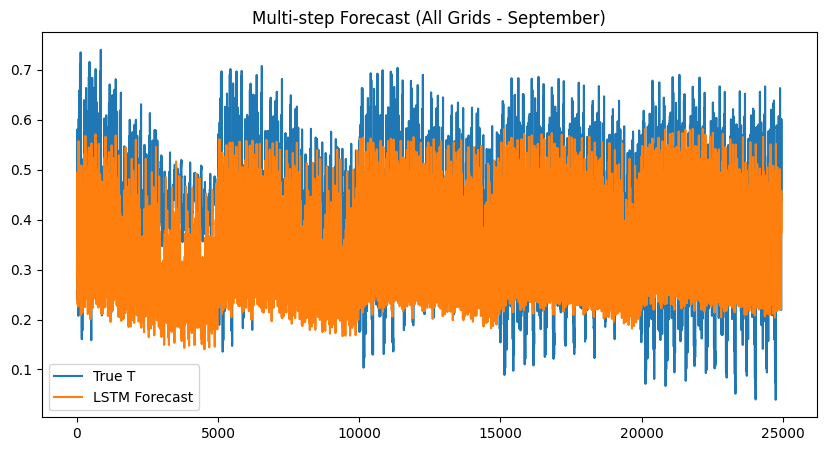

In [ ]:
all_preds = []
all_true  = []

for preds, true_T in multi_results:
    all_preds.append(preds)
    all_true.append(true_T)

all_preds = np.concatenate(all_preds)
all_true  = np.concatenate(all_true)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(all_true, label="True T")
plt.plot(all_preds, label="LSTM Forecast")
plt.legend()
plt.title("Multi-step Forecast (All Grids - September)")
plt.show()

In [ ]:
multi_step_records = []

for (lat, lon), group in test_df.groupby(["latitude", "longitude"]):

    group = group.sort_values("valid_time")
    data = group[["T","R","W"]].values
    times = group["valid_time"].values

    if len(data) <= SEQ_LEN:
        continue

    init_seq = data[:SEQ_LEN]
    future_exog = data[SEQ_LEN:, 1:]
    true_T = data[SEQ_LEN:, 0]
    future_times = times[SEQ_LEN:]

    seq = init_seq.copy()

    for i in range(len(future_exog)):

        x = torch.tensor(seq[np.newaxis,:,:], dtype=torch.float32).to(device)

        with torch.no_grad():
            pred_T = model(x).item()

        R_next, W_next = future_exog[i]
        next_step = np.array([pred_T, R_next, W_next])

        multi_step_records.append({
            "time": future_times[i],
            "latitude": lat,
            "longitude": lon,
            "true_T": true_T[i],
            "pred_T": pred_T
        })

        seq = np.vstack([seq[1:], next_step])

multi_step_df = pd.DataFrame(multi_step_records)

# Save
multi_step_df.to_csv("lstm_multi_step_september.csv", index=False)

Plot

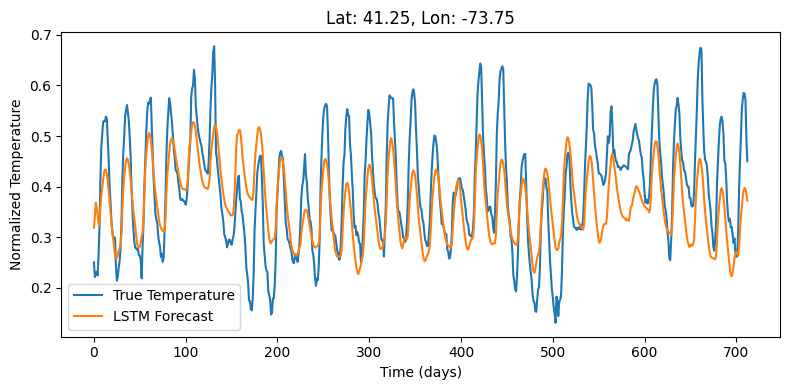

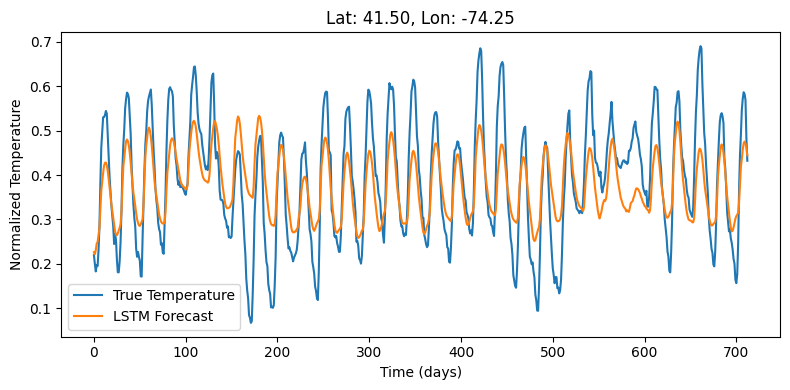

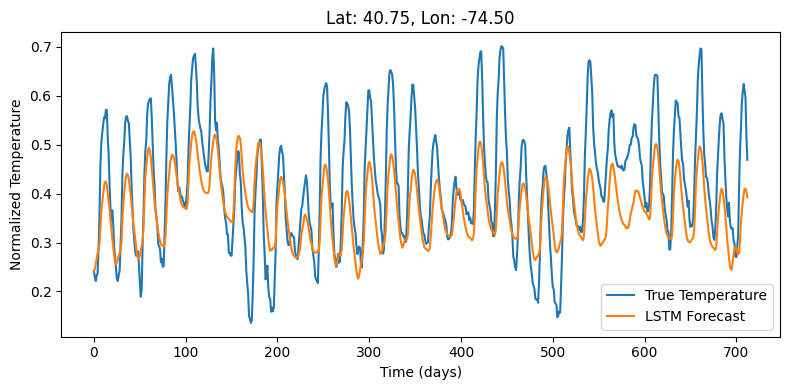

In [ ]:
import random
import matplotlib.pyplot as plt

# sample a few grids WITH coordinates
grouped = list(test_df.groupby(["latitude", "longitude"]))
sample_groups = random.sample(grouped, 3)

for i, ((lat, lon), group) in enumerate(sample_groups):

    group = group.sort_values("valid_time")
    data = group[["T","R","W"]].values

    if len(data) <= SEQ_LEN:
        continue

    # multi-step rollout
    init_seq = data[:SEQ_LEN]
    future_exog = data[SEQ_LEN:, 1:]
    true_T = data[SEQ_LEN:, 0]

    seq = init_seq.copy()
    preds = []

    for j in range(len(future_exog)):
        x = torch.tensor(seq[np.newaxis,:,:], dtype=torch.float32).to(device)

        with torch.no_grad():
            pred_T = model(x).item()

        R_next, W_next = future_exog[j]
        next_step = np.array([pred_T, R_next, W_next])

        preds.append(pred_T)
        seq = np.vstack([seq[1:], next_step])

    preds = np.array(preds)

    plt.figure(figsize=(8,4))
    plt.plot(true_T, label="True Temperature")
    plt.plot(preds, label="LSTM Forecast")

    plt.title(f"Lat: {lat:.2f}, Lon: {lon:.2f}")
    plt.xlabel("Time (days)")
    plt.ylabel("Normalized Temperature")
    plt.legend()
    plt.tight_layout()
    plt.show()

“Multi-step LSTM temperature forecasts at selected grid points (latitude, longitude shown in title). The model captures the dominant temporal patterns but exhibits amplitude damping and phase deviations over long horizons due to error accumulation.”

# Now Comparison Plot Between LSTM and SINDy Results

In [ ]:
lstm_df = pd.read_csv("lstm_multi_step_september.csv")
sindy_df = pd.read_csv("sindy_multi_grid_predictions_aligned.csv")

# keep only SINDy rows that belong to LSTM grid set
lstm_grids = lstm_df[["latitude", "longitude"]].drop_duplicates()

sindy_df_matched = sindy_df.merge(
    lstm_grids,
    on=["latitude", "longitude"],
    how="inner"
)

print("Original SINDy grids:", sindy_df[["latitude","longitude"]].drop_duplicates().shape[0])
print("Matched SINDy grids :", sindy_df_matched[["latitude","longitude"]].drop_duplicates().shape[0])

# save filtered file
sindy_df_matched.to_csv("sindy_multi_grid_predictions_matched35.csv", index=False)
print("Saved: sindy_multi_grid_predictions_matched35.csv")

Original SINDy grids: 45
Matched SINDy grids : 21
Saved: sindy_multi_grid_predictions_matched35.csv


In [ ]:
lstm_df   = pd.read_csv("lstm_multi_step_september.csv")
sindy_df  = pd.read_csv("sindy_multi_grid_predictions_aligned.csv")

comparison_df = lstm_df.merge(
    sindy_df,
    on=["time", "latitude", "longitude"],
    suffixes=("_lstm", "_sindy")
)

In [ ]:
comparison_df.size

0

Plot: True vs LSTM vs SINDy (per grid)

In [ ]:
import pandas as pd

lstm_df = pd.read_csv("lstm_multi_step_september.csv")
sindy_df = pd.read_csv("sindy_multi_grid_predictions_aligned.csv")

print("LSTM columns:", lstm_df.columns.tolist())
print("SINDy columns:", sindy_df.columns.tolist())

print("\nLSTM head:")
print(lstm_df.head())

print("\nSINDy head:")
print(sindy_df.head())

print("\nLSTM dtypes:")
print(lstm_df.dtypes)

print("\nSINDy dtypes:")
print(sindy_df.dtypes)

print("\nLSTM unique grids:", lstm_df[["latitude","longitude"]].drop_duplicates().shape[0])
print("SINDy unique grids:", sindy_df[["latitude","longitude"]].drop_duplicates().shape[0])

LSTM columns: ['time', 'latitude', 'longitude', 'true_T', 'pred_T']
SINDy columns: ['time', 'latitude', 'longitude', 'true_T', 'pred_T']

LSTM head:
                  time  latitude  longitude    true_T    pred_T
0  2025-09-01 07:00:00      40.5      -74.5  0.256675  0.283212
1  2025-09-01 08:00:00      40.5      -74.5  0.249754  0.289936
2  2025-09-01 09:00:00      40.5      -74.5  0.240738  0.298388
3  2025-09-01 10:00:00      40.5      -74.5  0.241744  0.299009
4  2025-09-01 11:00:00      40.5      -74.5  0.245494  0.302215

SINDy head:
                  time  latitude  longitude     true_T     pred_T
0  2025-06-01 07:00:00      40.0      -75.0  11.875763  12.103928
1  2025-06-01 08:00:00      40.0      -75.0  11.069611  12.130519
2  2025-06-01 09:00:00      40.0      -75.0  11.031403  12.162676
3  2025-06-01 10:00:00      40.0      -75.0  11.265839  12.201653
4  2025-06-01 11:00:00      40.0      -75.0  11.967133  12.222871

LSTM dtypes:
time          object
latitude     float64
lo

In [ ]:
lstm_grids = set(map(tuple, lstm_df[["latitude", "longitude"]].drop_duplicates().values))
sindy_grids = set(map(tuple, sindy_df[["latitude", "longitude"]].drop_duplicates().values))

print("Missing in LSTM:")
print(sorted(sindy_grids - lstm_grids))

print("\nExtra in LSTM:")
print(sorted(lstm_grids - sindy_grids))

Missing in LSTM:
[(np.float64(40.0), np.float64(-75.0)), (np.float64(40.0), np.float64(-74.75)), (np.float64(40.0), np.float64(-74.5)), (np.float64(40.0), np.float64(-74.25)), (np.float64(40.0), np.float64(-74.0)), (np.float64(40.0), np.float64(-73.75)), (np.float64(40.0), np.float64(-73.5)), (np.float64(40.0), np.float64(-73.25)), (np.float64(40.0), np.float64(-73.0)), (np.float64(40.25), np.float64(-75.0)), (np.float64(40.25), np.float64(-74.75)), (np.float64(40.25), np.float64(-74.5)), (np.float64(40.25), np.float64(-74.25)), (np.float64(40.25), np.float64(-74.0)), (np.float64(40.25), np.float64(-73.75)), (np.float64(40.25), np.float64(-73.5)), (np.float64(40.25), np.float64(-73.25)), (np.float64(40.25), np.float64(-73.0)), (np.float64(40.5), np.float64(-75.0)), (np.float64(40.5), np.float64(-74.75)), (np.float64(40.75), np.float64(-75.0)), (np.float64(40.75), np.float64(-74.75)), (np.float64(41.0), np.float64(-75.0)), (np.float64(41.0), np.float64(-74.75))]

Extra in LSTM:
[(np.flo

In [ ]:
print("LSTM test_df unique grids:", test_df[["latitude", "longitude"]].drop_duplicates().shape[0])

print("\nSorted LSTM test_df grids:")
print(
    sorted(
        set(map(tuple, test_df[["latitude", "longitude"]].drop_duplicates().values))
    )
)

LSTM test_df unique grids: 35

Sorted LSTM test_df grids:
[(np.float64(40.5), np.float64(-74.5)), (np.float64(40.5), np.float64(-74.25)), (np.float64(40.5), np.float64(-74.0)), (np.float64(40.5), np.float64(-73.75)), (np.float64(40.5), np.float64(-73.5)), (np.float64(40.5), np.float64(-73.25)), (np.float64(40.5), np.float64(-73.0)), (np.float64(40.75), np.float64(-74.5)), (np.float64(40.75), np.float64(-74.25)), (np.float64(40.75), np.float64(-74.0)), (np.float64(40.75), np.float64(-73.75)), (np.float64(40.75), np.float64(-73.5)), (np.float64(40.75), np.float64(-73.25)), (np.float64(40.75), np.float64(-73.0)), (np.float64(41.0), np.float64(-74.5)), (np.float64(41.0), np.float64(-74.25)), (np.float64(41.0), np.float64(-74.0)), (np.float64(41.0), np.float64(-73.75)), (np.float64(41.0), np.float64(-73.5)), (np.float64(41.0), np.float64(-73.25)), (np.float64(41.0), np.float64(-73.0)), (np.float64(41.25), np.float64(-74.5)), (np.float64(41.25), np.float64(-74.25)), (np.float64(41.25), np.fl

In [ ]:
lstm_df = pd.read_csv("lstm_multi_step_september.csv")
sindy_df = pd.read_csv("sindy_september_extrapolation_fixed_scaling.csv")

# keep only grids that exist in SINDy
common_grids = sindy_df[["latitude","longitude"]].drop_duplicates()

lstm_df_matched = lstm_df.merge(
    common_grids,
    on=["latitude","longitude"],
    how="inner"
)

print("LSTM grids after matching:",
      lstm_df_matched[["latitude","longitude"]].drop_duplicates().shape[0])

lstm_df_matched.to_csv("lstm_multi_step_matched21.csv", index=False)

LSTM grids after matching: 21


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# load training data (same used for LSTM training)
train_df = pd.read_csv("era5_sep2025_multigrid.csv")

# rename to match pipeline
train_df = train_df.rename(columns={
    "temp_C": "T",
    "ssrd": "R",
    "wind_speed": "W"
})

# rebuild scaler EXACTLY as before
scaler = MinMaxScaler()
scaler.fit(train_df[["T","R","W"]])

# load LSTM results
lstm_df = pd.read_csv("lstm_multi_step_matched21.csv")

# inverse transform ONLY T
def inverse_T(scaled_T):
    dummy = np.zeros((len(scaled_T), 3))
    dummy[:,0] = scaled_T   # put T in first column
    return scaler.inverse_transform(dummy)[:,0]

# apply inverse transform
lstm_df["true_T"] = inverse_T(lstm_df["true_T"].values)
lstm_df["pred_T"] = inverse_T(lstm_df["pred_T"].values)

# save corrected file
lstm_df.to_csv("lstm_multi_step_matched21_physical.csv", index=False)

print("Saved: lstm_multi_step_matched21_physical.csv")
print(lstm_df.head())

Saved: lstm_multi_step_matched21_physical.csv
                  time  latitude  longitude     true_T     pred_T
0  2025-09-01 07:00:00      40.5      -74.5  13.349468  13.972423
1  2025-09-01 08:00:00      40.5      -74.5  13.187005  14.130269
2  2025-09-01 09:00:00      40.5      -74.5  12.975349  14.328673
3  2025-09-01 10:00:00      40.5      -74.5  12.998961  14.343237
4  2025-09-01 11:00:00      40.5      -74.5  13.086995  14.418500


# Comparison Plot
Comparison of multi-step September temperature forecasts from LSTM and SINDy at selected common grid points. Both models are evaluated on the same overlapping spatial subset and shown in physical temperature units.

Merged rows: 14973
Merged grids: 21


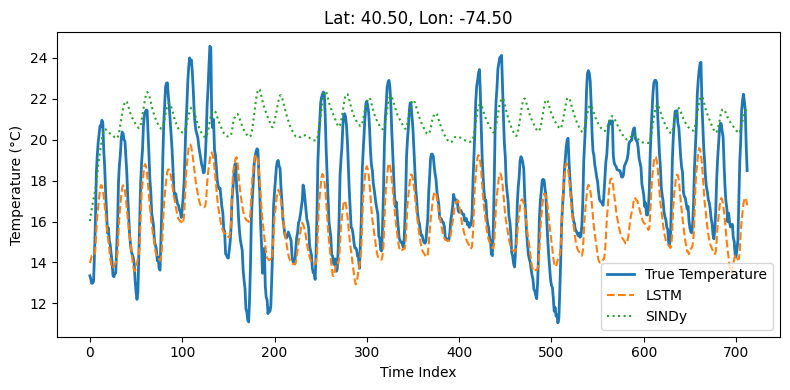

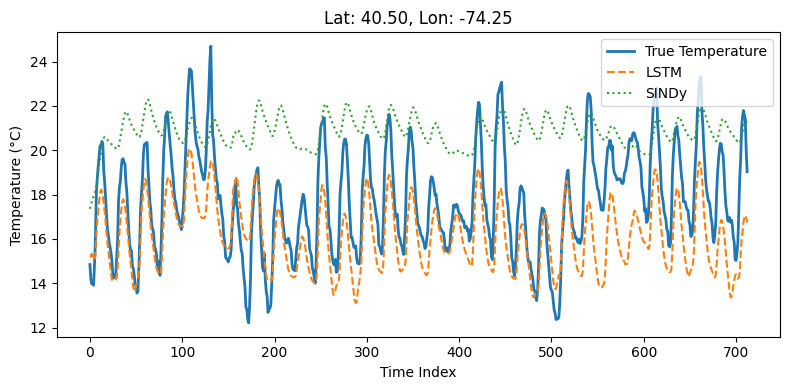

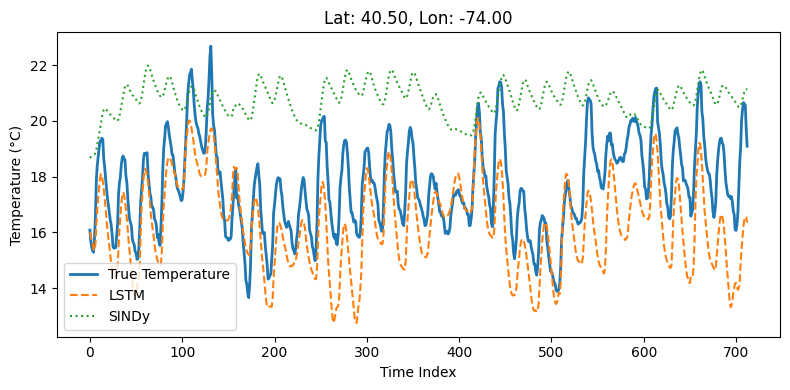

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

lstm_df = pd.read_csv("lstm_multi_step_matched21_physical.csv")
sindy_df = pd.read_csv("sindy_september_extrapolation_fixed_scaling.csv")

# standardize merge keys
for df_ in [lstm_df, sindy_df]:
    df_["time"] = pd.to_datetime(df_["time"])
    df_["latitude"] = df_["latitude"].round(4)
    df_["longitude"] = df_["longitude"].round(4)

comparison_df = lstm_df.merge(
    sindy_df,
    on=["time", "latitude", "longitude"],
    suffixes=("_lstm", "_sindy")
)

print("Merged rows:", len(comparison_df))
print("Merged grids:", comparison_df[["latitude", "longitude"]].drop_duplicates().shape[0])

groups = list(comparison_df.groupby(["latitude", "longitude"]))
selected_groups = groups[:min(3, len(groups))]

for (lat, lon), group in selected_groups:
    group = group.sort_values("time").reset_index(drop=True)

    plt.figure(figsize=(8,4))
    plt.plot(group["true_T_lstm"], label="True Temperature", linewidth=2)
    plt.plot(group["pred_T_lstm"], label="LSTM", linestyle="--")
    plt.plot(group["pred_T_sindy"], label="SINDy", linestyle=":")

    plt.title(f"Lat: {lat:.2f}, Lon: {lon:.2f}")
    plt.xlabel("Time Index")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.tight_layout()
    plt.show()

The LSTM model demonstrates strong phase alignment with observed temperature dynamics but exhibits amplitude damping during multi-step forecasting, indicating a loss of variability due to error accumulation. In contrast, the SINDy model preserves dynamical variability but introduces a systematic positive bias, likely due to limitations of the linear model structure. These results highlight a trade-off between data-driven flexibility and physics-based interpretability.

# LSTM September Validation (SINDy-style per-grid)

In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_squared_error

# load September data (same used in SINDy)
df_sep = pd.read_csv("era5_sep2025_multigrid.csv")
df_sep["valid_time"] = pd.to_datetime(df_sep["valid_time"])

# load trained LSTM model (already trained)
model.eval()

SEQ_LEN = 7
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lstm_records = []
lstm_metrics = []

for (lat, lon), df_g in df_sep.groupby(["latitude", "longitude"]):

    df_g = df_g.sort_values("valid_time").reset_index(drop=True)

    if len(df_g) <= SEQ_LEN:
        continue

    # raw variables
    T = df_g["temp_C"].values
    R = df_g["ssrd"].values
    W = df_g["wind_speed"].values
    times = df_g["valid_time"].values

    # -----------------------------
    # IMPORTANT: use SAME scaling as training
    # -----------------------------
    # (rebuild scaler from training data if needed)
    X_input = np.column_stack([T, R, W])
    X_scaled = scaler.transform(X_input)

    T_scaled = X_scaled[:, 0]

    # -----------------------------
    # prediction
    # -----------------------------
    T_pred_scaled = np.zeros_like(T_scaled)

    # copy truth for first SEQ_LEN
    T_pred_scaled[:SEQ_LEN] = T_scaled[:SEQ_LEN]

    for t in range(SEQ_LEN, len(T_scaled)):

        seq = X_scaled[t-SEQ_LEN:t]

        x = torch.tensor(seq[np.newaxis,:,:], dtype=torch.float32).to(device)

        with torch.no_grad():
            pred = model(x).item()

        T_pred_scaled[t] = pred

    # inverse transform to °C
    def inverse_T(scaled_T):
        dummy = np.zeros((len(scaled_T), 3))
        dummy[:,0] = scaled_T
        return scaler.inverse_transform(dummy)[:,0]

    T_pred = inverse_T(T_pred_scaled)
    T_true = T

    # -----------------------------
    # save (same format as SINDy)
    # -----------------------------
    grid_df = pd.DataFrame({
        "time": times[SEQ_LEN:],
        "latitude": lat,
        "longitude": lon,
        "true_T": T_true[SEQ_LEN:],
        "pred_T": T_pred[SEQ_LEN:]
    })

    lstm_records.append(grid_df)

    rmse = np.sqrt(mean_squared_error(T_true[SEQ_LEN:], T_pred[SEQ_LEN:]))
    corr = np.corrcoef(T_true[SEQ_LEN:], T_pred[SEQ_LEN:])[0,1]

    lstm_metrics.append({
        "latitude": lat,
        "longitude": lon,
        "rmse": rmse,
        "correlation": corr
    })

# combine all grids
lstm_sep_df = pd.concat(lstm_records, ignore_index=True)
lstm_metrics_df = pd.DataFrame(lstm_metrics)

# save
lstm_sep_df.to_csv("lstm_september_pergrid.csv", index=False)
lstm_metrics_df.to_csv("lstm_september_pergrid_metrics.csv", index=False)

print("Saved: lstm_september_pergrid.csv")
print("Saved: lstm_september_pergrid_metrics.csv")

print("Unique grids:", lstm_sep_df[["latitude","longitude"]].drop_duplicates().shape[0])
print("Total rows:", len(lstm_sep_df))

overall_rmse = np.sqrt(mean_squared_error(lstm_sep_df["true_T"], lstm_sep_df["pred_T"]))
print("Overall RMSE:", overall_rmse)
print("Mean RMSE:", lstm_metrics_df["rmse"].mean())
print("Mean Correlation:", lstm_metrics_df["correlation"].mean())

Final Comparison of Global LSTM Model Vs SINDy Per Grid Model

Merged rows: 14973
Merged grids: 21
LSTM RMSE on common subset: 0.46277871178009705
SINDy RMSE on common subset: 2.9823437165686633
LSTM Corr on common subset: 0.9890907820494188
SINDy Corr on common subset: 0.3097116577989362


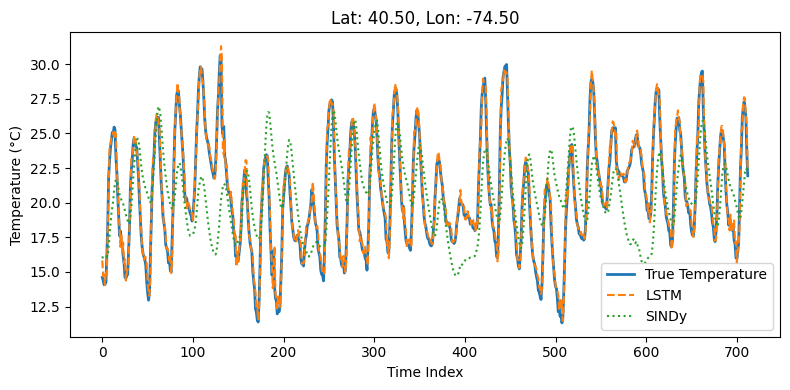

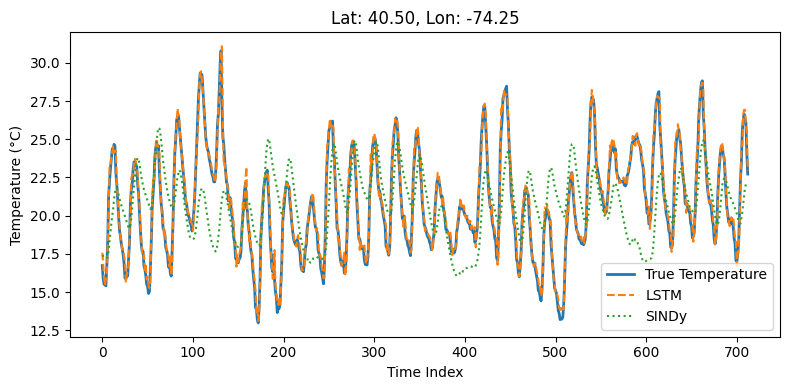

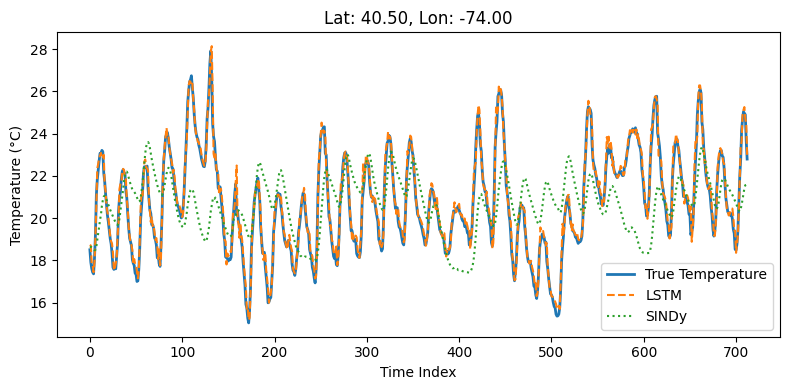

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# load outputs
lstm_df = pd.read_csv("lstm_september_pergrid.csv")
sindy_df = pd.read_csv("sindy_september_extrapolation.csv")

# standardize keys
for df_ in [lstm_df, sindy_df]:
    df_["time"] = pd.to_datetime(df_["time"])
    df_["latitude"] = pd.to_numeric(df_["latitude"]).round(4)
    df_["longitude"] = pd.to_numeric(df_["longitude"]).round(4)

# keep only common rows
comparison_df = lstm_df.merge(
    sindy_df,
    on=["time", "latitude", "longitude"],
    suffixes=("_lstm", "_sindy")
)

print("Merged rows:", len(comparison_df))
print("Merged grids:", comparison_df[["latitude", "longitude"]].drop_duplicates().shape[0])

# metrics on the same common subset
rmse_lstm = np.sqrt(mean_squared_error(
    comparison_df["true_T_lstm"], comparison_df["pred_T_lstm"]
))
rmse_sindy = np.sqrt(mean_squared_error(
    comparison_df["true_T_lstm"], comparison_df["pred_T_sindy"]
))

corr_lstm = np.corrcoef(comparison_df["true_T_lstm"], comparison_df["pred_T_lstm"])[0, 1]
corr_sindy = np.corrcoef(comparison_df["true_T_lstm"], comparison_df["pred_T_sindy"])[0, 1]

print("LSTM RMSE on common subset:", rmse_lstm)
print("SINDy RMSE on common subset:", rmse_sindy)
print("LSTM Corr on common subset:", corr_lstm)
print("SINDy Corr on common subset:", corr_sindy)

# plot 3 example grids
groups = list(comparison_df.groupby(["latitude", "longitude"]))
selected_groups = groups[:min(3, len(groups))]

for (lat, lon), group in selected_groups:
    group = group.sort_values("time").reset_index(drop=True)

    plt.figure(figsize=(8,4))
    plt.plot(group["true_T_lstm"], label="True Temperature", linewidth=2)
    plt.plot(group["pred_T_lstm"], label="LSTM", linestyle="--")
    plt.plot(group["pred_T_sindy"], label="SINDy", linestyle=":")
    plt.title(f"Lat: {lat:.2f}, Lon: {lon:.2f}")
    plt.xlabel("Time Index")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.tight_layout()
    plt.show()

Saved: lstm_september_freerun.csv
Saved: lstm_september_freerun_metrics.csv
Unique grids: 35
Total rows: 24955
Overall RMSE: 6.881693486123832
Mean RMSE: 6.762497474862201
Mean Correlation: 0.6414025534370009

Merged rows: 14973
Merged grids: 21
Free-running LSTM RMSE on common subset: 6.040034545631181
Free-running SINDy RMSE on common subset: 2.9823437165686633
Free-running LSTM Corr on common subset: 0.6043795295268494
Free-running SINDy Corr on common subset: 0.3097116577989362


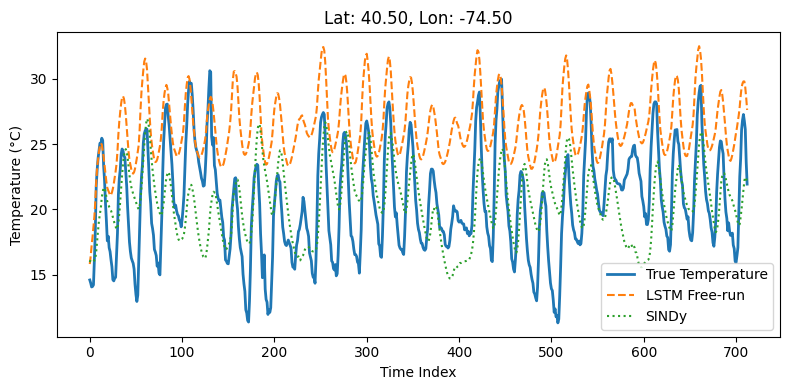

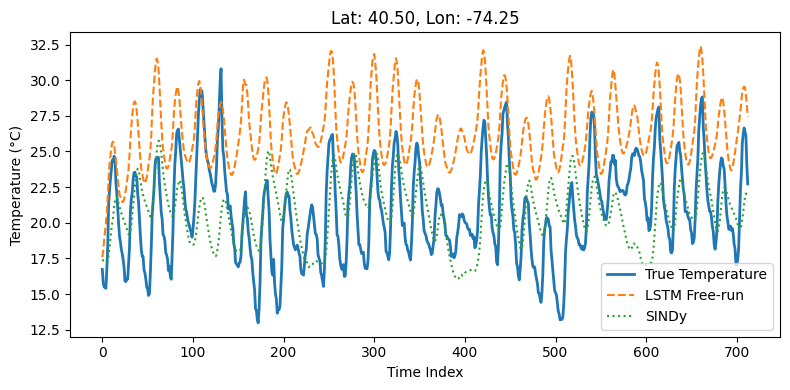

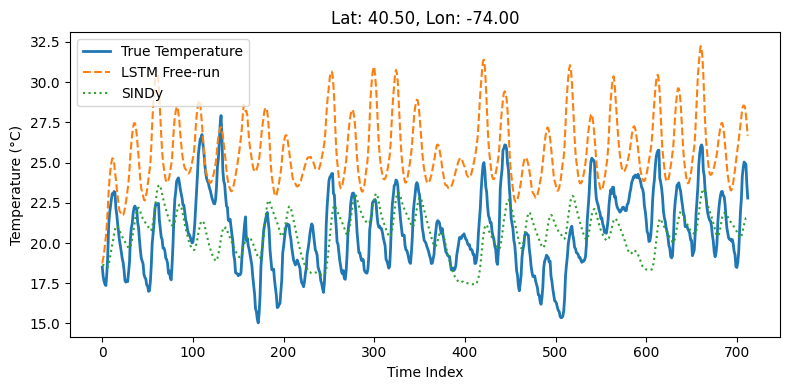

In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# -----------------------------
# 1) Load September data
# -----------------------------
df_sep = pd.read_csv("era5_sep2025_multigrid.csv")
df_sep["valid_time"] = pd.to_datetime(df_sep["valid_time"])

# -----------------------------
# 2) Load trained LSTM model
# Assumes:
# - model is already loaded in memory
# - scaler is the SAME MinMaxScaler used during LSTM training
# -----------------------------
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEQ_LEN = 7

# -----------------------------
# 3) Free-running per-grid LSTM rollout
# -----------------------------
lstm_free_records = []
lstm_free_metrics = []

for (lat, lon), df_g in df_sep.groupby(["latitude", "longitude"]):

    df_g = df_g.sort_values("valid_time").reset_index(drop=True)

    if len(df_g) <= SEQ_LEN:
        continue

    # raw September variables
    T = df_g["temp_C"].values
    R = df_g["ssrd"].values
    W = df_g["wind_speed"].values
    times = df_g["valid_time"].values

    # scale with SAME training scaler used in LSTM training
    X_raw = pd.DataFrame({
        "T": T,
        "R": R,
        "W": W
    })
    X_scaled = scaler.transform(X_raw)

    T_scaled = X_scaled[:, 0]
    R_scaled = X_scaled[:, 1]
    W_scaled = X_scaled[:, 2]

    # initialize with true first SEQ_LEN steps
    T_pred_scaled = np.zeros_like(T_scaled)
    T_pred_scaled[:SEQ_LEN] = T_scaled[:SEQ_LEN]

    # free-running rollout:
    # after SEQ_LEN, feed predicted T back into the next input window
    for t in range(SEQ_LEN, len(T_scaled)):

        seq = np.zeros((SEQ_LEN, 3))

        for k in range(SEQ_LEN):
            idx = t - SEQ_LEN + k
            seq[k, 0] = T_pred_scaled[idx]   # predicted/history T
            seq[k, 1] = R_scaled[idx]        # true R
            seq[k, 2] = W_scaled[idx]        # true W

        x = torch.tensor(seq[np.newaxis, :, :], dtype=torch.float32).to(device)

        with torch.no_grad():
            pred_T_scaled = model(x).item()

        T_pred_scaled[t] = pred_T_scaled

    # inverse transform T back to physical units
    dummy = np.zeros((len(T_pred_scaled), 3))
    dummy[:, 0] = T_pred_scaled
    T_pred = scaler.inverse_transform(dummy)[:, 0]

    # save only forecast portion after initialization
    grid_df = pd.DataFrame({
        "time": times[SEQ_LEN:],
        "latitude": lat,
        "longitude": lon,
        "true_T": T[SEQ_LEN:],
        "pred_T": T_pred[SEQ_LEN:]
    })

    lstm_free_records.append(grid_df)

    rmse = np.sqrt(mean_squared_error(T[SEQ_LEN:], T_pred[SEQ_LEN:]))
    corr = np.corrcoef(T[SEQ_LEN:], T_pred[SEQ_LEN:])[0, 1] if len(T[SEQ_LEN:]) > 1 else np.nan

    lstm_free_metrics.append({
        "latitude": lat,
        "longitude": lon,
        "rmse": rmse,
        "correlation": corr
    })

# combine all grids
lstm_free_df = pd.concat(lstm_free_records, ignore_index=True)
lstm_free_metrics_df = pd.DataFrame(lstm_free_metrics)

# save
lstm_free_df.to_csv("lstm_september_freerun.csv", index=False)
lstm_free_metrics_df.to_csv("lstm_september_freerun_metrics.csv", index=False)

print("Saved: lstm_september_freerun.csv")
print("Saved: lstm_september_freerun_metrics.csv")
print("Unique grids:", lstm_free_df[["latitude", "longitude"]].drop_duplicates().shape[0])
print("Total rows:", len(lstm_free_df))

overall_rmse = np.sqrt(mean_squared_error(lstm_free_df["true_T"], lstm_free_df["pred_T"]))
print("Overall RMSE:", overall_rmse)
print("Mean RMSE:", lstm_free_metrics_df["rmse"].mean())
print("Mean Correlation:", lstm_free_metrics_df["correlation"].mean())

# -----------------------------
# 4) Match to SINDy common grids and compare
# -----------------------------
sindy_df = pd.read_csv("sindy_september_extrapolation.csv")
sindy_df["time"] = pd.to_datetime(sindy_df["time"])

lstm_free_df["time"] = pd.to_datetime(lstm_free_df["time"])

for df_ in [lstm_free_df, sindy_df]:
    df_["latitude"] = pd.to_numeric(df_["latitude"]).round(4)
    df_["longitude"] = pd.to_numeric(df_["longitude"]).round(4)

comparison_df = lstm_free_df.merge(
    sindy_df,
    on=["time", "latitude", "longitude"],
    suffixes=("_lstm", "_sindy")
)

print("\nMerged rows:", len(comparison_df))
print("Merged grids:", comparison_df[["latitude", "longitude"]].drop_duplicates().shape[0])

rmse_lstm = np.sqrt(mean_squared_error(
    comparison_df["true_T_lstm"], comparison_df["pred_T_lstm"]
))
rmse_sindy = np.sqrt(mean_squared_error(
    comparison_df["true_T_lstm"], comparison_df["pred_T_sindy"]
))

corr_lstm = np.corrcoef(comparison_df["true_T_lstm"], comparison_df["pred_T_lstm"])[0, 1]
corr_sindy = np.corrcoef(comparison_df["true_T_lstm"], comparison_df["pred_T_sindy"])[0, 1]

print("Free-running LSTM RMSE on common subset:", rmse_lstm)
print("Free-running SINDy RMSE on common subset:", rmse_sindy)
print("Free-running LSTM Corr on common subset:", corr_lstm)
print("Free-running SINDy Corr on common subset:", corr_sindy)

# -----------------------------
# 5) Plot a few comparison grids
# -----------------------------
groups = list(comparison_df.groupby(["latitude", "longitude"]))
selected_groups = groups[:min(3, len(groups))]

for (lat, lon), group in selected_groups:
    group = group.sort_values("time").reset_index(drop=True)

    plt.figure(figsize=(8, 4))
    plt.plot(group["true_T_lstm"], label="True Temperature", linewidth=2)
    plt.plot(group["pred_T_lstm"], label="LSTM Free-run", linestyle="--")
    plt.plot(group["pred_T_sindy"], label="SINDy", linestyle=":")
    plt.title(f"Lat: {lat:.2f}, Lon: {lon:.2f}")
    plt.xlabel("Time Index")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.tight_layout()
    plt.show()

Merged rows: 14973
Merged grids: 21
True multi-step LSTM RMSE on common subset: 4.373185544666337
True multi-step SINDy RMSE on common subset: 2.9823437165686633
True multi-step LSTM Corr on common subset: 0.5411354210259185
True multi-step SINDy Corr on common subset: 0.3097116577989363
Saved: comparison_true_multistep_lstm_vs_sindy.csv


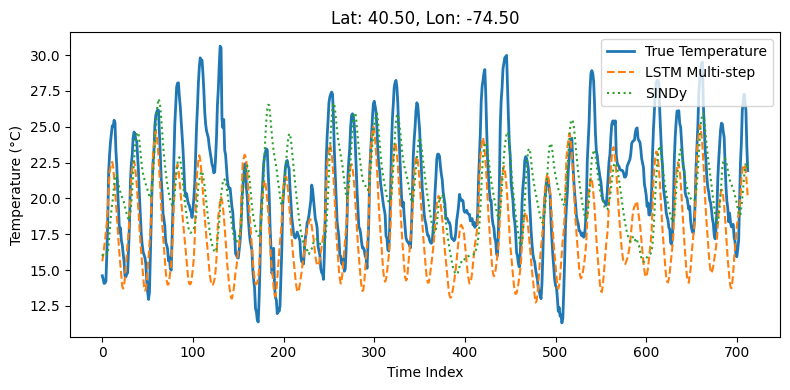

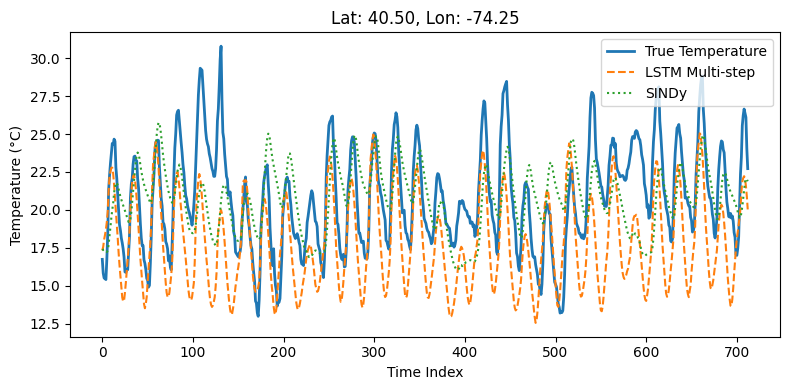

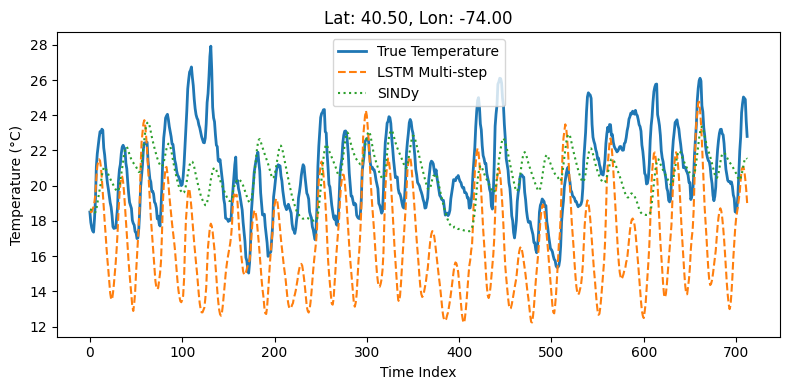

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# --------------------------------------------------
# 1) Rebuild the SAME LSTM scaler from summer training data
# --------------------------------------------------
train_raw = pd.read_csv("era5_nyc_summer_accum.csv", parse_dates=["valid_time"])

scaler = MinMaxScaler()
scaler.fit(train_raw[["temp_C", "ssrd", "wind_speed"]])

def inverse_T(scaled_T):
    dummy = np.zeros((len(scaled_T), 3))
    dummy[:, 0] = scaled_T
    return scaler.inverse_transform(dummy)[:, 0]

# --------------------------------------------------
# 2) Load the ORIGINAL true multi-step LSTM file
# --------------------------------------------------
lstm_df = pd.read_csv("lstm_multi_step_september.csv")

# convert normalized T back to physical units
lstm_df["true_T"] = inverse_T(lstm_df["true_T"].values)
lstm_df["pred_T"] = inverse_T(lstm_df["pred_T"].values)

# optional: save corrected physical-units version
lstm_df.to_csv("lstm_multi_step_september_physical.csv", index=False)

# --------------------------------------------------
# 3) Load the CORRECT SINDy file
# --------------------------------------------------
sindy_df = pd.read_csv("sindy_september_extrapolation.csv")

# --------------------------------------------------
# 4) Standardize merge keys
# --------------------------------------------------
for df_ in [lstm_df, sindy_df]:
    df_["time"] = pd.to_datetime(df_["time"])
    df_["latitude"] = pd.to_numeric(df_["latitude"]).round(4)
    df_["longitude"] = pd.to_numeric(df_["longitude"]).round(4)

# --------------------------------------------------
# 5) Keep only common rows/grids/timestamps
# --------------------------------------------------
comparison_df = lstm_df.merge(
    sindy_df,
    on=["time", "latitude", "longitude"],
    suffixes=("_lstm", "_sindy")
)

print("Merged rows:", len(comparison_df))
print("Merged grids:", comparison_df[["latitude", "longitude"]].drop_duplicates().shape[0])

# --------------------------------------------------
# 6) Metrics on the common subset
# --------------------------------------------------
rmse_lstm = np.sqrt(mean_squared_error(
    comparison_df["true_T_lstm"], comparison_df["pred_T_lstm"]
))
rmse_sindy = np.sqrt(mean_squared_error(
    comparison_df["true_T_lstm"], comparison_df["pred_T_sindy"]
))

corr_lstm = np.corrcoef(
    comparison_df["true_T_lstm"], comparison_df["pred_T_lstm"]
)[0, 1]
corr_sindy = np.corrcoef(
    comparison_df["true_T_lstm"], comparison_df["pred_T_sindy"]
)[0, 1]

print("True multi-step LSTM RMSE on common subset:", rmse_lstm)
print("True multi-step SINDy RMSE on common subset:", rmse_sindy)
print("True multi-step LSTM Corr on common subset:", corr_lstm)
print("True multi-step SINDy Corr on common subset:", corr_sindy)

# --------------------------------------------------
# 7) Save merged comparison file
# --------------------------------------------------
comparison_df.to_csv("comparison_true_multistep_lstm_vs_sindy.csv", index=False)
print("Saved: comparison_true_multistep_lstm_vs_sindy.csv")

# --------------------------------------------------
# 8) Plot a few common grids
# --------------------------------------------------
groups = list(comparison_df.groupby(["latitude", "longitude"]))
selected_groups = groups[:min(3, len(groups))]

for (lat, lon), group in selected_groups:
    group = group.sort_values("time").reset_index(drop=True)

    plt.figure(figsize=(8, 4))
    plt.plot(group["true_T_lstm"], label="True Temperature", linewidth=2)
    plt.plot(group["pred_T_lstm"], label="LSTM Multi-step", linestyle="--")
    plt.plot(group["pred_T_sindy"], label="SINDy", linestyle=":")
    plt.title(f"Lat: {lat:.2f}, Lon: {lon:.2f}")
    plt.xlabel("Time Index")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.tight_layout()
    plt.show()